
========== Camera Pose (Without Line Merging) ==========
Yaw   : -0.22 degree
Pitch : 0.11 degree
Roll  : 3.72 degree


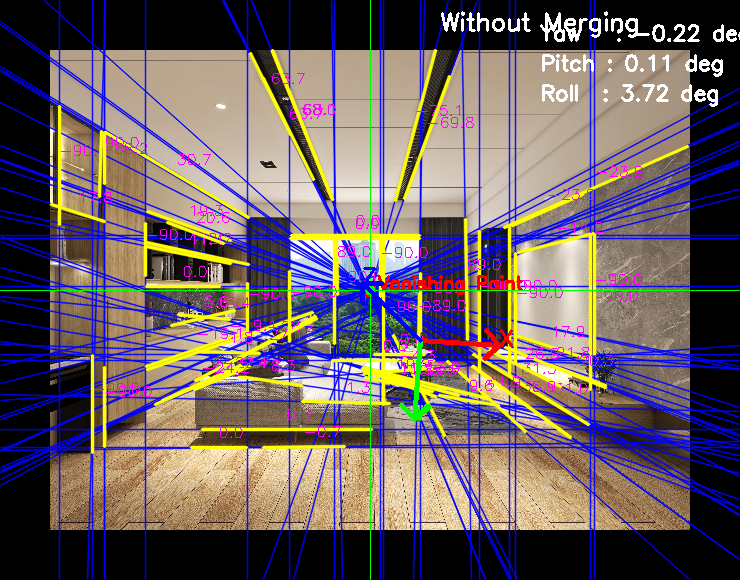

原始結果已儲存：/content/drive/MyDrive/嵌入式影像/picture/test_picture_1_camera_pose_result_raw.png

========== Camera Pose (Without Line Merging, No Extended Lines) ==========


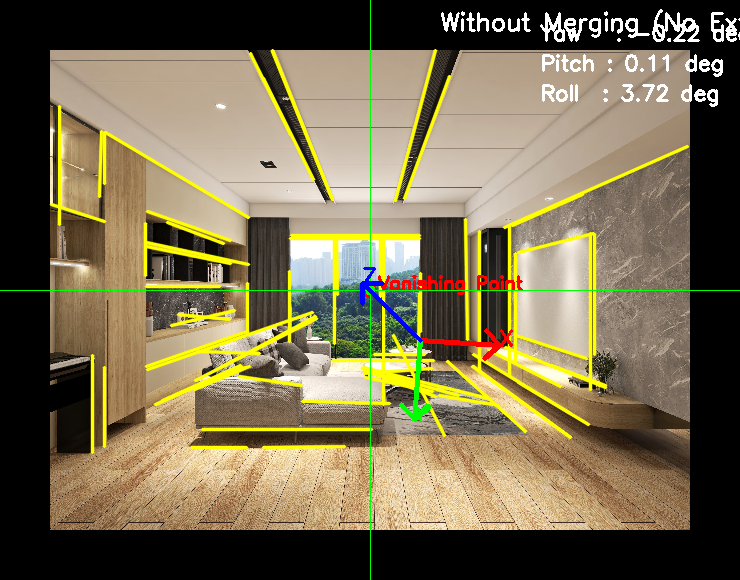

原始結果 (無延伸線) 已儲存：/content/drive/MyDrive/嵌入式影像/picture/test_picture_1_camera_pose_result_raw_no_extended.png

========== Camera Pose (With Line Merging) ==========
Yaw   : -0.11 degree
Pitch : 0.11 degree
Roll  : 7.01 degree


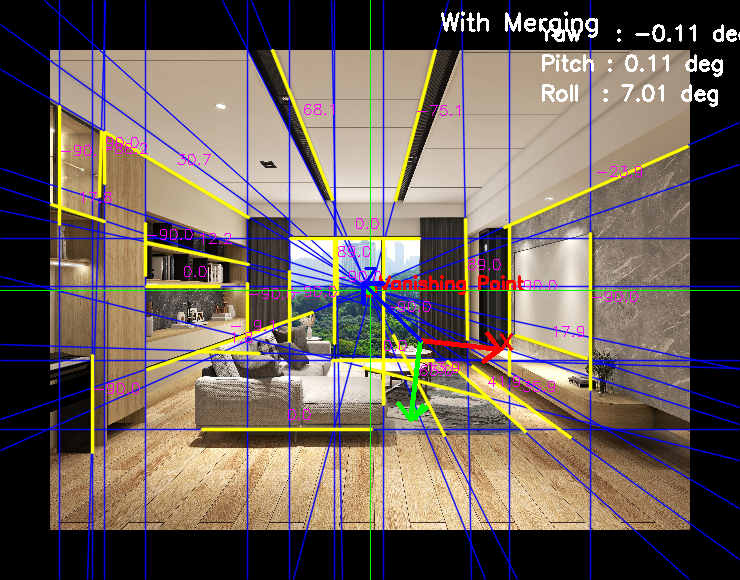

合併後結果已儲存：/content/drive/MyDrive/嵌入式影像/picture/test_picture_1_camera_pose_result_merged.png

========== Camera Pose (With Line Merging, No Extended Lines) ==========


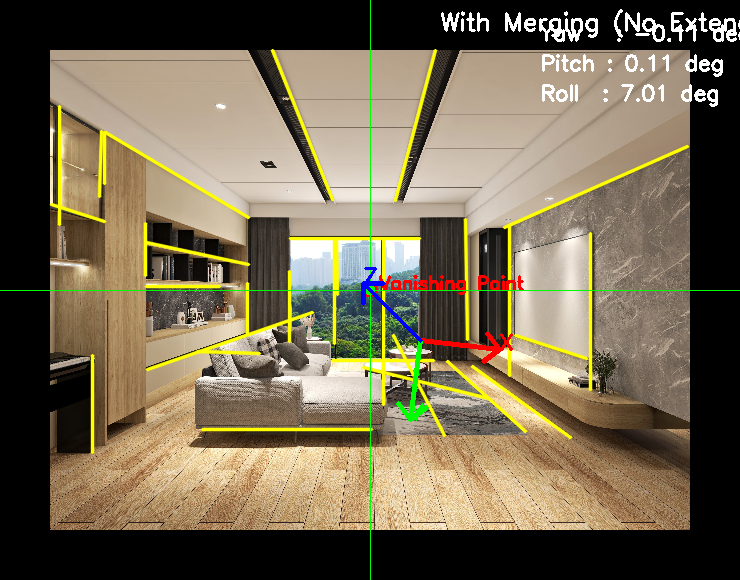

合併後結果 (無延伸線) 已儲存：/content/drive/MyDrive/嵌入式影像/picture/test_picture_1_camera_pose_result_merged_no_extended.png


In [ ]:
import cv2
import numpy as np
import math
import os
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab display


# =========================
# 1. 讀取圖片，支援中文路徑
# =========================
def read_image(path):
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError("圖片讀取失敗，請檢查路徑")

    # 灰階圖轉 BGR，方便後面畫彩色線
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # 如果有 alpha 通道，轉成 BGR
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    return img


# =========================
# 2. 影像前處理
# =========================
def preprocess(img):
    img_resized = cv2.resize(img, (640, 480))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 自適應 Canny 參數
    median = np.median(blur)
    lower = int(max(0, 0.66 * median))
    upper = int(min(255, 1.33 * median))

    edges = cv2.Canny(blur, lower, upper)

    return img_resized, gray, edges


# =========================
# 3. Hough Line 偵測
# =========================
def detect_hough_lines(edges):
    lines_raw = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=60,
        minLineLength=50,
        maxLineGap=15
    )

    result = []

    if lines_raw is None:
        return result

    for line in lines_raw:
        x1, y1, x2, y2 = line[0]

        length = math.hypot(x2 - x1, y2 - y1)

        if length < 40:
            continue

        # Inline calculate_line_angle
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        if angle > 90:
            angle -= 180
        if angle < -90:
            angle += 180

        result.append((x1, y1, x2, y2, length, angle)) # Add angle to the tuple

    return result


# =========================
# 3.1 線段合併 (如果鄰近且方向接近的線刪除只保留最長的)
# =========================

# Helper to calculate distance between two points
def dist_points(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

# Helper to calculate distance from a point to a line segment
def distance_point_to_segment(point, seg_start, seg_end):
    px, py = point
    ax, ay = seg_start
    bx, by = seg_end

    # Vector from A to B
    AB_vec = (bx - ax, by - ay)
    # Vector from A to P
    AP_vec = (px - ax, py - ay)

    len_sq_AB = AB_vec[0]**2 + AB_vec[1]**2

    # If segment is a point (A == B)
    if len_sq_AB == 0:
        return math.hypot(px - ax, py - ay)

    # Calculate the projection of AP onto AB
    dot_product = AP_vec[0] * AB_vec[0] + AP_vec[1] * AB_vec[1]
    t = dot_product / len_sq_AB

    if t < 0.0:  # Closest point is A
        closest_x, closest_y = ax, ay
    elif t > 1.0: # Closest point is B
        closest_x = bx
        closest_y = by
    else:        # Closest point is on the segment
        closest_x = ax + t * AB_vec[0]
        closest_y = ay + t * AB_vec[1]

    return math.hypot(px - closest_x, py - closest_y)

# Helper to calculate the shortest distance between two line segments
def distance_segment_to_segment(line1_coords, line2_coords):
    x1, y1, x2, y2 = line1_coords
    x3, y3, x4, y4 = line2_coords

    # Check distances from endpoints of line1 to line2
    d1 = distance_point_to_segment((x1, y1), (x3, y3), (x4, y4))
    d2 = distance_point_to_segment((x2, y2), (x3, y3), (x4, y4))

    # Check distances from endpoints of line2 to line1
    d3 = distance_point_to_segment((x3, y3), (x1, y1), (x2, y2))
    d4 = distance_point_to_segment((x4, y4), (x1, y1), (x2, y2))

    # The shortest distance between the two segments is the minimum of these four point-to-segment distances
    # (This assumes segments don't cross. If they cross, distance is 0. This can be added if needed, but for proximity, min of these is usually good enough)
    return min(d1, d2, d3, d4)

# New function to merge similar lines
def merge_similar_lines(lines, angle_threshold=5, dist_threshold=30):
    if not lines:
        return []

    merged_lines = []
    used_indices = [False] * len(lines)

    for i in range(len(lines)):
        if used_indices[i]:
            continue

        current_group = [lines[i]]
        used_indices[i] = True
        x1_i, y1_i, x2_i, y2_i, len_i, angle_i = lines[i]
        line1_coords = (x1_i, y1_i, x2_i, y2_i)

        for j in range(i + 1, len(lines)):
            if used_indices[j]:
                continue

            x1_j, y1_j, x2_j, y2_j, len_j, angle_j = lines[j]
            line2_coords = (x1_j, y1_j, x2_j, y2_j)

            # Check angle similarity
            if abs(angle_i - angle_j) < angle_threshold:
                # Check proximity using shortest segment-to-segment distance
                if distance_segment_to_segment(line1_coords, line2_coords) < dist_threshold:
                    current_group.append(lines[j])
                    used_indices[j] = True

        # From the current group, keep the longest line
        longest_line = max(current_group, key=lambda line: line[4])
        merged_lines.append(longest_line)

    return merged_lines


# =========================
# 5. 計算兩條線交點
# =========================
def intersection(line1, line2):
    x1, y1, x2, y2, _, _ = line1 # Unpack line1 with angle
    x3, y3, x4, y4, _, _ = line2 # Unpack line2 with angle

    # Inline line_to_abc
    a1 = y1 - y2
    b1 = x2 - x1
    c1 = x1 * y2 - x2 * y1

    a2 = y3 - y4
    b2 = x4 - x3
    c2 = x3 * y4 - x4 * y3

    det = a1 * b2 - a2 * b1

    if abs(det) < 1e-6:
        return None

    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det

    return x, y


# =========================
# 6. 找視線消失點
# =========================
def find_vanishing_point(lines, width=640, height=480):
    candidate_intersections_with_lines = []

    # Collect all intersection candidates along with the indices of the lines that formed them
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            p = intersection(lines[i], lines[j])

            if p is None:
                continue

            x, y = p

            # Filter out points that are too far outside the image
            if -width * 2 < x < width * 3 and -height * 2 < y < height * 3:
                candidate_intersections_with_lines.append(((x, y), i, j))

    if not candidate_intersections_with_lines:
        return None

    # Cluster these intersection points
    clusters = []  # Each cluster will be a list of (point, line_idx1, line_idx2)

    # Threshold for grouping points into a cluster (e.g., 20 pixels)
    clustering_threshold = 20

    for current_intersection_data in candidate_intersections_with_lines:
        point = current_intersection_data[0]
        added_to_cluster = False
        for cluster in clusters:
            # Check if this point is close to the representative point (first point) of an existing cluster
            # For a more robust approach, one might check against the cluster centroid
            if dist_points(point, cluster[0][0]) < clustering_threshold:
                cluster.append(current_intersection_data)
                added_to_cluster = True
                break
        if not added_to_cluster:
            clusters.append([current_intersection_data])  # Start a new cluster

    if not clusters:
        return None

    best_cluster = None
    max_support = -1

    # Find the cluster with the maximum number of unique supporting lines
    for cluster in clusters:
        unique_lines_in_cluster = set()
        for _, line_idx1, line_idx2 in cluster:
            unique_lines_in_cluster.add(line_idx1)
            unique_lines_in_cluster.add(line_idx2)

        support = len(unique_lines_in_cluster)

        if support > max_support:
            max_support = support
            best_cluster = cluster

    if best_cluster is None:
        return None

    # Calculate the centroid (median) of the points in the best cluster
    best_cluster_points = np.array([data[0] for data in best_cluster])
    vp_x = int(np.median(best_cluster_points[:, 0]))
    vp_y = int(np.median(best_cluster_points[:, 1]))

    return vp_x, vp_y


# =========================
# 7. 估算 Roll
# =========================
def estimate_roll(lines):
    angles = []

    for x1, y1, x2, y2, length, angle in lines: # Unpack angle
        # The angle is already normalized in calculate_line_angle
        # So we just need to filter for 'horizontal' lines
        if abs(angle) < 45:
            angles.append(angle)

    if len(angles) == 0:
        return 0.0

    return float(np.median(angles))


# =========================
# 8. 由消失點估算 yaw / pitch
# =========================
def estimate_yaw_pitch(vp, width=640, height=480):
    fx = 0.8 * width
    fy = 0.8 * width
    cx = width / 2
    cy = height / 2

    vp_x, vp_y = vp

    yaw = math.degrees(math.atan2(vp_x - cx, fx))
    pitch = -math.degrees(math.atan2(vp_y - cy, fy))

    return yaw, pitch


# =========================
# 9. 畫相機座標軸
# =========================
def draw_camera_axis(img, vp, roll, origin_offset=(0, 0)):
    h, w = img.shape[:2]
    cx_orig, cy_orig = w // 2, h // 2 # Center of the original image
    
    # Adjust the center of the original image by the offset
    cx = cx_orig + origin_offset[0]
    cy = cy_orig + origin_offset[1]

    axis_len = 80

    roll_rad = math.radians(roll)

    # X 軸：紅色
    x_end = (
        int(cx + axis_len * math.cos(roll_rad)),
        int(cy + axis_len * math.sin(roll_rad))
    )

    # Y 軸：綠色
    y_end = (
        int(cx - axis_len * math.sin(roll_rad)),
        int(cy + axis_len * math.cos(roll_rad))
    )

    # Z 軸：藍色，指向消失點方向
    if vp is not None:
        # vp coordinates are already adjusted by origin_offset before being passed to draw_camera_axis
        vx, vy = vp
        dx = vx - cx
        dy = vy - cy
        norm = math.hypot(dx, dy)

        if norm > 1:
            z_end = (
                int(cx + axis_len * dx / norm),
                int(cy + axis_len * dy / norm)
            )
        else:
            z_end = (cx, cy - axis_len)
    else:
        z_end = (cx, cy - axis_len)

    cv2.arrowedLine(img, (cx, cy), x_end, (0, 0, 255), 3, tipLength=0.25)
    cv2.arrowedLine(img, (cx, cy), y_end, (0, 255, 0), 3, tipLength=0.25)
    cv2.arrowedLine(img, (cx, cy), z_end, (255, 0, 0), 3, tipLength=0.25)

    cv2.putText(img, "X", x_end, cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(img, "Y", y_end, cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(img, "Z", z_end, cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# Helper function to get line intersection points with image boundary
def get_line_boundary_points(a_coeff, b_coeff, c_coeff, w, h):
    boundary_points = []
    epsilon = 2.0 # Pixels for unique point comparison

    # Intersection with y=0 (top edge): a_coeff * x + c_coeff = 0
    if a_coeff != 0: # Avoid division by zero for vertical lines
        x_intersect = -c_coeff / a_coeff
        if 0 <= x_intersect <= w:
            boundary_points.append((int(x_intersect), 0))

    # Intersection with y=h-1 (bottom edge): a_coeff * x + b_coeff * (h-1) + c_coeff = 0
    if a_coeff != 0: # Avoid division by zero for vertical lines
        x_intersect = (-c_coeff - b_coeff * (h - 1)) / a_coeff
        if 0 <= x_intersect <= w:
            boundary_points.append((int(x_intersect), h - 1))

    # Intersection with x=0 (left edge): b_coeff * y + c_coeff = 0
    if b_coeff != 0: # Avoid division by zero for horizontal lines
        y_intersect = -c_coeff / b_coeff
        if 0 <= y_intersect <= h:
            boundary_points.append((0, int(y_intersect)))

    # Intersection with x=w-1 (right edge): a_coeff * (w-1) + b_coeff * y + c_coeff = 0
    if b_coeff != 0: # Avoid division by zero for horizontal lines
        y_intersect = (-c_coeff - a_coeff * (w - 1)) / b_coeff
        if 0 <= y_intersect <= h:
            boundary_points.append((w - 1, int(y_intersect)))

    unique_points = []
    for p_new in boundary_points:
        is_unique = True
        for p_existing in unique_points:
            if abs(p_new[0] - p_existing[0]) < epsilon and abs(p_new[1] - p_existing[1]) < epsilon:
                is_unique = False
                break
        if is_unique:
            unique_points.append(p_new)

    return unique_points


# =========================
# 10. 畫結果
# =========================
def draw_result(img, lines, vp, yaw, pitch, roll, title_suffix="", draw_extended_lines=True, display_angles=True):
    original_h, original_w = img.shape[:2]
    output = img.copy()

    # Initial min/max coordinates encompassing the original image
    min_x = 0
    max_x = original_w
    min_y = 0
    max_y = original_h

    # Adjust bounds to include vanishing point if it exists
    if vp is not None:
        vp_x, vp_y = vp
        min_x = min(min_x, vp_x)
        max_x = max(max_x, vp_x)
        min_y = min(min_y, vp_y)
        max_y = max(max_y, vp_y)

    # Add a minimal padding around the entire scene (original image + VP)
    adaptive_padding = 50 # Minimal padding to add around the outermost points
    min_x -= adaptive_padding
    max_x += adaptive_padding
    min_y -= adaptive_padding
    max_y += adaptive_padding

    # Calculate new canvas dimensions
    new_w = max_x - min_x
    new_h = max_y - min_y

    # Calculate offset needed to place (min_x, min_y) of the scene at (0,0) of the new canvas
    offset_x = -min_x
    offset_y = -min_y

    # Create new blank (black) canvas if dimensions changed
    if new_w > original_w or new_h > original_h or min_x < 0 or min_y < 0 or max_x > original_w or max_y > original_h:
        expanded_output = np.zeros((new_h, new_w, 3), dtype=np.uint8)
        # Copy the original image to its new position on the expanded canvas
        expanded_output[offset_y:offset_y + original_h, offset_x:offset_x + original_w] = output
        output = expanded_output
        h, w = new_h, new_w

        # Adjust vanishing point coordinates for the new canvas
        if vp is not None:
            vp = (vp[0] + offset_x, vp[1] + offset_y)

    else:
        h, w = original_h, original_w
        offset_x, offset_y = 0, 0 # No offset if canvas not expanded

    # Draw extended Hough Lines
    if draw_extended_lines:
        for x1, y1, x2, y2, length, angle in lines:
            # Adjust line coordinates for the potential canvas expansion
            x1_adj, y1_adj = x1 + offset_x, y1 + offset_y
            x2_adj, y2_adj = x2 + offset_x, y2 + offset_y

            # Inline line_to_abc for extended lines
            A_coeff = y1_adj - y2_adj
            B_coeff = x2_adj - x1_adj
            C_coeff = x1_adj * y2_adj - x2_adj * y1_adj

            extended_points = get_line_boundary_points(A_coeff, B_coeff, C_coeff, w, h)

            if len(extended_points) >= 2:
                # Draw the extended line in blue, thinner
                cv2.line(output, extended_points[0], extended_points[1], (255, 0, 0), 1, cv2.LINE_AA)
    
    # Always draw the original detected segment on top in yellow, thicker
    for x1, y1, x2, y2, length, angle in lines:
        # Adjust line coordinates for the potential canvas expansion
        x1_adj, y1_adj = x1 + offset_x, y1 + offset_y
        x2_adj, y2_adj = x2 + offset_x, y2 + offset_y

        cv2.line(output, (x1_adj, y1_adj), (x2_adj, y2_adj), (0, 255, 255), 2, cv2.LINE_AA)
        # Display the angle next to the line
        if display_angles:
            mid_x = (x1_adj + x2_adj) // 2
            mid_y = (y1_adj + y2_adj) // 2
            cv2.putText(output, f"{angle:.1f}", (mid_x, mid_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 1)

    # 畫消失點
    if vp is not None:
        vp_x, vp_y = vp
        cv2.circle(output, (vp_x, vp_y), 8, (0, 0, 255), -1)
        cv2.putText(output, "Vanishing Point", (vp_x + 10, vp_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # 畫中心十字線 (of the original image, adjusted for offset)
    cx_orig_img, cy_orig_img = original_w // 2, original_h // 2
    cx_canvas, cy_canvas = cx_orig_img + offset_x, cy_orig_img + offset_y

    cv2.line(output, (cx_canvas, 0), (cx_canvas, h), (0, 255, 0), 1) # Vertical line
    cv2.line(output, (0, cy_canvas), (w, cy_canvas), (0, 255, 0), 1) # Horizontal line
    cv2.circle(output, (cx_canvas, cy_canvas), 5, (0, 255, 0), -1) # Center dot

    # 畫相機座標軸 (pass adjusted vp and original image center offset)
    draw_camera_axis(output, vp, roll, origin_offset=(offset_x, offset_y))

    # 畫 yaw pitch roll 文字
    # Adjust positions for top-right corner, stacked
    text_start_x = w - 200 # Adjust as needed based on text length
    text_start_y = 40

    cv2.putText(output, f"Yaw   : {yaw:.2f} deg", (text_start_x, text_start_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(output, f"Pitch : {pitch:.2f} deg", (text_start_x, text_start_y + 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.putText(output, f"Roll  : {roll:.2f} deg", (text_start_x, text_start_y + 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Add a title to the image
    if title_suffix:
        cv2.putText(output, title_suffix, (w - 300, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    return output


# Helper function to process lines and display results
def process_and_display(original_img, lines, scenario_name, output_dir, img_filename, draw_extended_lines=True, display_angles=True):
    print(f"\n========== Camera Pose ({scenario_name}) ==========")
    
    vp = find_vanishing_point(lines)
    if vp is not None:
        yaw, pitch = estimate_yaw_pitch(vp)
    else:
        yaw, pitch = 0.0, 0.0
    roll = estimate_roll(lines)
    
    result_img = draw_result(original_img, lines, vp, yaw, pitch, roll, 
                             title_suffix=scenario_name, 
                             draw_extended_lines=draw_extended_lines, 
                             display_angles=display_angles)

    print(f"Yaw   : {yaw:.2f} degree")
    print(f"Pitch : {pitch:.2f} degree")
    print(f"Roll  : {roll:.2f} degree")
    cv2_imshow(result_img)
    save_path = os.path.join(output_dir, f"{img_filename}_camera_pose_result_{scenario_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.png")
    cv2.imwrite(save_path, result_img)
    print(f"結果已儲存：{save_path}")


# =========================
# 11. 主程式
# =========================
def main():
    img_path = "/content/drive/MyDrive/嵌入式影像/picture/test_picture_1.png"
    output_dir = "/content/drive/MyDrive/嵌入式影像/picture"

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Extract the base filename without extension
    img_filename = os.path.splitext(os.path.basename(img_path))[0]

    img = read_image(img_path)

    original, gray, edges = preprocess(img)

    raw_lines = detect_hough_lines(edges) # Get raw lines with angles

    # --- Scenario 1: Without line merging ---
    process_and_display(original, raw_lines, "Without Merging", output_dir, img_filename, draw_extended_lines=True, display_angles=True)

    # --- Scenario 1.5: Without line merging (no extended lines) ---
    process_and_display(original, raw_lines, "Without Merging (No Extended)", output_dir, img_filename, draw_extended_lines=False, display_angles=False)

    # --- Scenario 2: With line merging ---
    # Adjust these parameters to fine-tune line merging
    angle_threshold = 10  # degrees
    dist_threshold = 40  # pixels
    lines_merged = merge_similar_lines(raw_lines, angle_threshold=angle_threshold, dist_threshold=dist_threshold) # Merge similar lines

    process_and_display(original, lines_merged, "With Merging", output_dir, img_filename, draw_extended_lines=True, display_angles=True)

    # --- Scenario 2.5: With line merging (no extended lines) ---
    process_and_display(original, lines_merged, "With Merging (No Extended)", output_dir, img_filename, draw_extended_lines=False, display_angles=False)

    # cv2.waitKey(0)
    # cv2.destroyAllWindows()


if __name__ == "__main__":
    main()